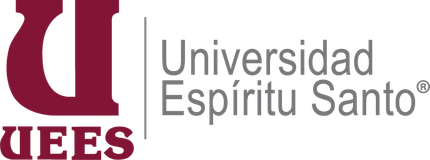

<div style="background:#821436;color:#FFFFFF;padding:14px 18px;border-radius:10px;margin:6px 0 12px 0"><div style="font-size:12px;letter-spacing:.08em;text-transform:uppercase;opacity:.9">Aprendizaje Automático · MIAR0525 · Semana 1 · Versión resuelta · referencia</div><div style="font-size:22px;font-weight:700;margin-top:4px">E1.1 · Tipos de aprendizaje y proceso ML</div><div style="font-size:12px;opacity:.9;margin-top:4px">Postgrado · Maestría en Inteligencia Artificial · UEES</div></div>

| | |
|---|---|
| **Objetivo** | Ver con tus propios números qué es aprender, generalizar y sobreajustar, y reconocer las tres familias de aprendizaje. |
| **Resultado de aprendizaje** | RDA1 · competencias CG-G1 y CE-G1 |
| **Duración** | ≈ 4 h (el Nivel 1 es el **prelaboratorio**: hazlo antes de la clase sincrónica) |
| **Teoría** | Manual M1 §2 (tipos de aprendizaje) y §4 (proceso y generalización) · Animaciones A1.1 y A1.5 · Video V1.1 |
| **Datos** | Sintéticos · California Housing (`fetch_california_housing`, StatLib; 20 640 distritos, 8 variables) |

**Niveles:** 1 · algoritmo desde cero en NumPy → 2 · lo mismo con scikit-learn → 3 · datos reales → 4 · reto.
Completa las celdas marcadas con `# TODO` y ejecuta la **autoverificación** al final.

## 0 · Configuración

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from cycler import cycler

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 2026
UEES = {"vino": "#821436", "azul": "#1F6F8B", "ocre": "#C28E0E", "verde": "#3A7D44", "gris": "#77787B"}
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=list(UEES.values())), "axes.titlecolor": UEES["vino"],
    "axes.titleweight": "bold", "axes.edgecolor": UEES["gris"], "axes.grid": True, "grid.color": "#EEE8EA",
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
print(f"scikit-learn {sklearn.__version__} · semilla {SEED}")

scikit-learn 1.9.1 · semilla 2026


## Nivel 1 · Desde cero (prelaboratorio)

### 1.1 Aprender una curva y ver el sobreajuste

Generamos 30 puntos de una curva conocida con ruido, $y = \sin(2.8x) + \varepsilon$. En la vida real no conocemos la curva: solo vemos los puntos. Vamos a:

1. separar **a mano** 20 puntos de entrenamiento y 10 de validación;
2. ajustar polinomios de grado 1 a 12 por mínimos cuadrados;
3. comparar el error en entrenamiento y en validación.

In [2]:
rng = np.random.default_rng(SEED)
n = 30
x = rng.uniform(-1, 1, n)
y = np.sin(2.8 * x) + rng.normal(0, 0.25, n)

# TODO: baraja los índices 0..29 con `rng.permutation` y separa 20 para entrenamiento y 10 para validación.
indices = rng.permutation(n)
idx_tr, idx_va = indices[:20], indices[20:]
x_tr, y_tr, x_va, y_va = x[idx_tr], y[idx_tr], x[idx_va], y[idx_va]
print(f"entrenamiento: {len(x_tr)} puntos · validación: {len(x_va)} puntos")

entrenamiento: 20 puntos · validación: 10 puntos


Un polinomio de grado $d$ es un modelo lineal en los parámetros: $\hat y = \beta_0 + \beta_1 x + \dots + \beta_d x^d = X\beta$, donde cada columna de la matriz $X$ es una potencia de $x$ (matriz de Vandermonde). Los mínimos cuadrados eligen $\beta$ que minimiza $\lVert y - X\beta\rVert^2$.

In [3]:
def matriz_polinomial(x, grado):
    """Columnas 1, x, x², …, x^grado."""
    return np.vander(x, grado + 1, increasing=True)


def ajustar_polinomio(x, y, grado):
    """Devuelve los coeficientes β que minimizan el error cuadrático."""
    # TODO: usa matriz_polinomial y np.linalg.lstsq (rcond=None) para obtener β.
    X = matriz_polinomial(x, grado)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta


def predecir(beta, x):
    return matriz_polinomial(x, len(beta) - 1) @ beta


def mse(y, y_pred):
    """Error cuadrático medio."""
    # TODO: devuelve el promedio de (y - y_pred)²
    return float(np.mean((np.asarray(y) - np.asarray(y_pred)) ** 2))


grados = range(1, 13)
errores_tr, errores_va = {}, {}
for d in grados:
    beta = ajustar_polinomio(x_tr, y_tr, d)
    errores_tr[d] = mse(y_tr, predecir(beta, x_tr))
    errores_va[d] = mse(y_va, predecir(beta, x_va))

mejor_grado = min(errores_va, key=errores_va.get)
tabla = pd.DataFrame({"ECM entrenamiento": errores_tr, "ECM validación": errores_va}).rename_axis("grado")
print(tabla.to_string(float_format=lambda v: f"{v:,.4f}"))
print(f"\nGrado con menor error de validación: {mejor_grado}")

       ECM entrenamiento  ECM validación
grado                                   
1                 0.1575          0.2826
2                 0.1309          0.4883
3                 0.0783          0.1409
4                 0.0782          0.1880
5                 0.0771          0.2912
6                 0.0742         14.2955
7                 0.0214      1,764.1194
8                 0.0190      3,950.9723
9                 0.0161          7.4266
10                0.0161         24.9113
11                0.0160      7,035.9004
12                0.0121 11,282,647.9276

Grado con menor error de validación: 3


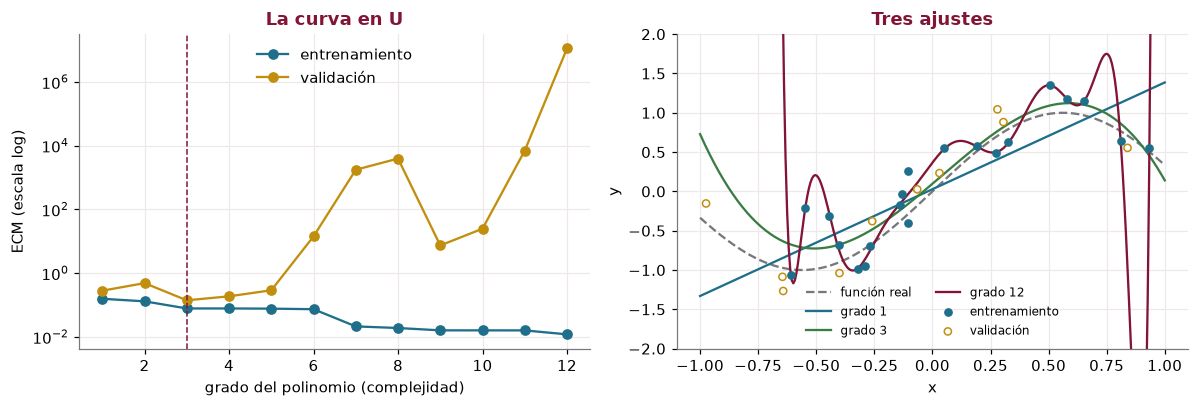

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(list(grados), list(errores_tr.values()), "o-", label="entrenamiento", color=UEES["azul"])
axes[0].plot(list(grados), list(errores_va.values()), "o-", label="validación", color=UEES["ocre"])
axes[0].axvline(mejor_grado, color=UEES["vino"], ls="--", lw=1)
axes[0].set(yscale="log", xlabel="grado del polinomio (complejidad)", ylabel="ECM (escala log)", title="La curva en U")
axes[0].legend()

malla = np.linspace(-1, 1, 300)
axes[1].plot(malla, np.sin(2.8 * malla), color=UEES["gris"], ls="--", label="función real")
for d, color in ((1, UEES["azul"]), (mejor_grado, UEES["verde"]), (12, UEES["vino"])):
    axes[1].plot(malla, predecir(ajustar_polinomio(x_tr, y_tr, d), malla), color=color, label=f"grado {d}")
axes[1].scatter(x_tr, y_tr, s=22, color=UEES["azul"], zorder=3, label="entrenamiento")
axes[1].scatter(x_va, y_va, s=22, facecolors="none", edgecolors=UEES["ocre"], zorder=3, label="validación")
axes[1].set(ylim=(-2, 2), xlabel="x", ylabel="y", title="Tres ajustes")
axes[1].legend(fontsize=8, ncols=2)
plt.tight_layout()
plt.show()

**Qué observar.** El error de entrenamiento baja siempre al subir el grado; el de validación baja, toca un mínimo y vuelve a subir. Con grado 1 hay **subajuste** (sesgo alto); con grado 12 la curva persigue el ruido entre los puntos: **sobreajuste** (varianza alta). El grado se elige por el error de **validación**, nunca por el de entrenamiento. Compara con la animación A1.5.

### 1.2 Aprender de recompensas: el bandido multibrazo

Un agente tiene 4 máquinas tragamonedas con probabilidades de premio desconocidas. En cada jugada elige una, recibe 1 (premio) o 0 y actualiza su estimación $Q(a)$ de cada máquina. Con la estrategia **ε-greedy** explora al azar con probabilidad $\varepsilon$ y, si no, juega la mejor conocida.

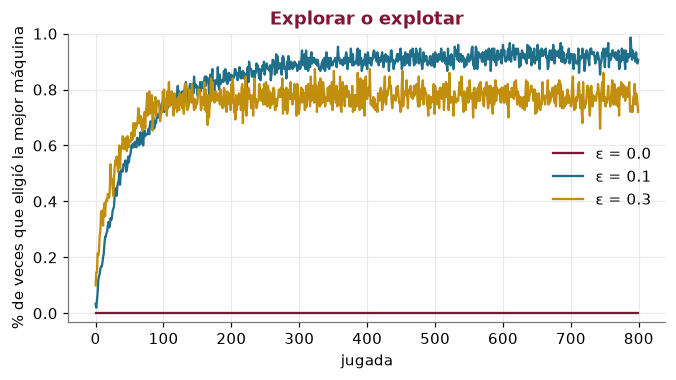

ε = 0.0: elige la mejor máquina el 0% de las veces al final
ε = 0.1: elige la mejor máquina el 92% de las veces al final
ε = 0.3: elige la mejor máquina el 77% de las veces al final


In [5]:
MU = np.array([0.20, 0.50, 0.75, 0.35])      # probabilidades reales (el agente no las conoce)


def epsilon_greedy(mu, eps, pasos, rng):
    """Devuelve un arreglo booleano: ¿eligió la mejor máquina en cada paso?"""
    k = len(mu)
    Q, N = np.zeros(k), np.zeros(k)
    eligio_optima = np.zeros(pasos, dtype=bool)
    for t in range(pasos):
        # TODO: con probabilidad eps elige una máquina al azar; si no, la de mayor Q.
        #       Recibe la recompensa (1 con probabilidad mu[a]) y actualiza el promedio incremental de Q[a].
        a = int(rng.integers(k)) if rng.random() < eps else int(np.argmax(Q))
        r = float(rng.random() < mu[a])
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
        eligio_optima[t] = a == np.argmax(mu)
    return eligio_optima


rng_b = np.random.default_rng(SEED)
curvas = {eps: np.mean([epsilon_greedy(MU, eps, 800, rng_b) for _ in range(150)], axis=0) for eps in (0.0, 0.1, 0.3)}
fig, ax = plt.subplots(figsize=(7, 3.4))
for eps, curva in curvas.items():
    ax.plot(curva, label=f"ε = {eps}")
ax.set(xlabel="jugada", ylabel="% de veces que eligió la mejor máquina", title="Explorar o explotar", ylim=(-0.03, 1))
ax.legend()
plt.show()
for eps, curva in curvas.items():
    print(f"ε = {eps}: elige la mejor máquina el {curva[-100:].mean():.0%} de las veces al final")

**Qué observar.** Con $\varepsilon = 0$ el agente se queda con la primera máquina que le dio premio, aunque no sea la mejor: nunca explora. Con algo de exploración descubre la mejor. Es el dilema central del aprendizaje por refuerzo (M1 §2, animación A1.1).

## Nivel 2 · Lo mismo con scikit-learn

### 2.1 Regresión polinómica con `Pipeline`
`PolynomialFeatures` construye las potencias de $x$ y `LinearRegression` resuelve los mínimos cuadrados. Con la misma partición, el resultado debe coincidir con tu versión del Nivel 1.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

GRADO = 3
# TODO: arma un pipeline PolynomialFeatures(GRADO, include_bias=False) + LinearRegression y entrénalo con x_tr.
modelo_poli = make_pipeline(PolynomialFeatures(GRADO, include_bias=False), LinearRegression())
modelo_poli.fit(x_tr.reshape(-1, 1), y_tr)
mse_sklearn = mean_squared_error(y_va, modelo_poli.predict(x_va.reshape(-1, 1)))
mse_propio = mse(y_va, predecir(ajustar_polinomio(x_tr, y_tr, GRADO), x_va))
print(f"ECM validación · scikit-learn: {mse_sklearn:.6f} · tu versión: {mse_propio:.6f}")
assert np.isclose(mse_sklearn, mse_propio, rtol=1e-6), "Tu ajuste del Nivel 1 no coincide con scikit-learn."
print("✓ Coinciden")

ECM validación · scikit-learn: 0.140880 · tu versión: 0.140880
✓ Coinciden


### 2.2 Partición, baseline y un vistazo al aprendizaje no supervisado
`train_test_split` hace la partición (con semilla) y `DummyRegressor` da el **baseline**: predecir siempre la media.

In [7]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

X2 = x.reshape(-1, 1)
X2_tr, X2_va, y2_tr, y2_va = train_test_split(X2, y, test_size=1 / 3, random_state=SEED)
base = DummyRegressor(strategy="mean").fit(X2_tr, y2_tr)
poli = make_pipeline(PolynomialFeatures(GRADO, include_bias=False), LinearRegression()).fit(X2_tr, y2_tr)
ecm_base = mean_squared_error(y2_va, base.predict(X2_va))
ecm_poli = mean_squared_error(y2_va, poli.predict(X2_va))
print(f"ECM validación · baseline (media): {ecm_base:.3f} · polinomio grado {GRADO}: {ecm_poli:.3f}")

ECM validación · baseline (media): 0.266 · polinomio grado 3: 0.093


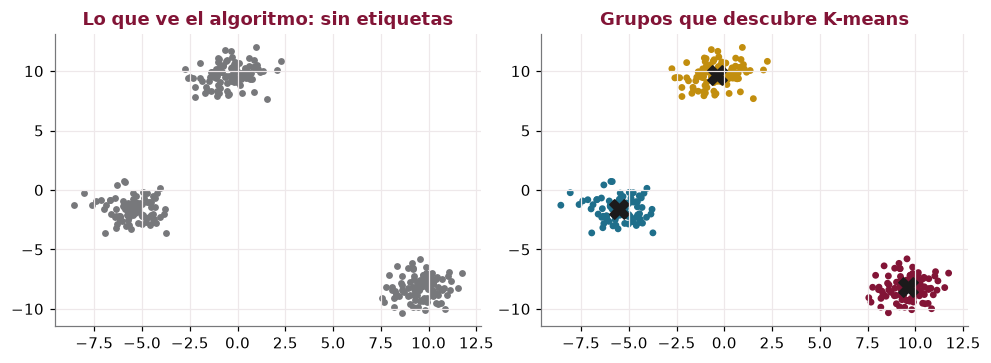

In [8]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X_blobs, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.9, random_state=SEED)   # descartamos las etiquetas
kmeans = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_blobs)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], s=12, color=UEES["gris"])
axes[0].set(title="Lo que ve el algoritmo: sin etiquetas")
axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], s=12, c=[list(UEES.values())[k] for k in kmeans.labels_])
axes[1].scatter(*kmeans.cluster_centers_.T, marker="X", s=160, color="#1C1A1B")
axes[1].set(title="Grupos que descubre K-means")
plt.tight_layout()
plt.show()

## Nivel 3 · Datos reales: California Housing

Cada fila es un distrito censal de California (1990); el objetivo `MedHouseVal` es el valor mediano de la vivienda en cientos de miles de dólares. Vamos a comparar un **baseline** con una **regresión lineal** usando validación cruzada, como en todo proyecto serio.

In [9]:
from sklearn.datasets import fetch_california_housing

casas = fetch_california_housing(as_frame=True)
X_c, y_c = casas.data, casas.target
print(X_c.shape)
X_c.describe().T.round(2)

(20640, 8)


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
HouseAge,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
AveRooms,20640.0,5.43,2.47,0.85,4.44,5.23,6.05,141.91
AveBedrms,20640.0,1.10,0.47,0.33,1.01,1.05,1.10,34.07
Population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
AveOccup,20640.0,3.07,10.39,0.69,2.43,2.82,3.28,1243.33
Latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
Longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31


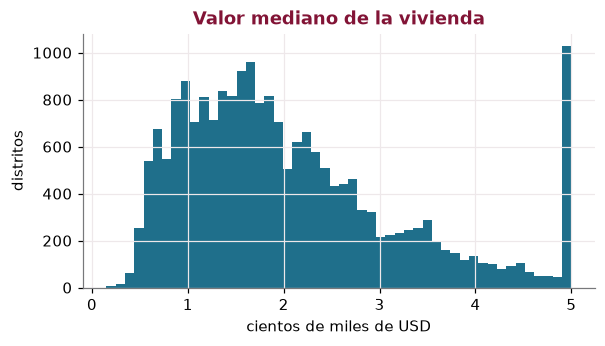

Distritos con el valor tope de 5.0: 992 → el objetivo está censurado (atención al interpretar errores altos).


In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(y_c, bins=50, color=UEES["azul"])
ax.set(title="Valor mediano de la vivienda", xlabel="cientos de miles de USD", ylabel="distritos")
plt.show()
print(f"Distritos con el valor tope de 5.0: {(y_c >= 5).sum()} → el objetivo está censurado (atención al interpretar errores altos).")

Primero se separa la **prueba** (20 %) y no se toca más. Sobre el resto, validación cruzada de 5 folds.

In [11]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import StandardScaler

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_c, y_c, test_size=0.2, random_state=SEED)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
modelos = {
    "baseline (media)": DummyRegressor(strategy="mean"),
    "regresión lineal": make_pipeline(StandardScaler(), LinearRegression()),
}
filas = {}
for nombre, est in modelos.items():
    # TODO: usa cross_validate con cv y scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error"].
    res = cross_validate(est, Xc_tr, yc_tr, cv=cv, scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error"])
    mae, rmse = -res["test_neg_mean_absolute_error"], -res["test_neg_root_mean_squared_error"]
    filas[nombre] = {"MAE": f"{mae.mean():.3f} ± {mae.std():.3f}", "RMSE": f"{rmse.mean():.3f} ± {rmse.std():.3f}",
                     "MAE_media": mae.mean()}
resultados_cv = pd.DataFrame(filas).T
resultados_cv[["MAE", "RMSE"]]

,MAE,RMSE
baseline (media),0.915 ± 0.011,1.158 ± 0.013
regresión lineal,0.532 ± 0.005,0.726 ± 0.010


### Curva de aprendizaje
¿Mejoraría el modelo con más datos? La curva de aprendizaje entrena con subconjuntos crecientes y mide el error en entrenamiento y validación.

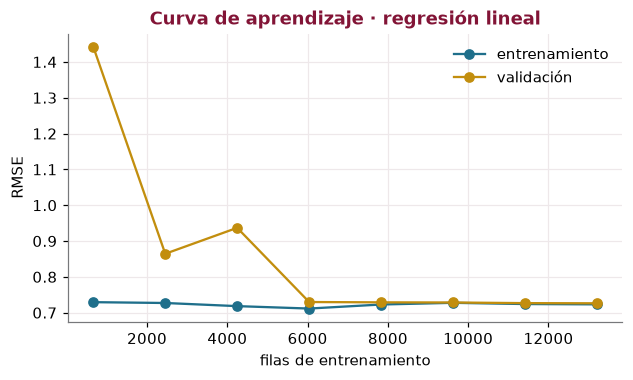

In [12]:
from sklearn.model_selection import learning_curve

tamanos, err_tr, err_va = learning_curve(
    make_pipeline(StandardScaler(), LinearRegression()), Xc_tr, yc_tr, cv=cv,
    train_sizes=np.linspace(0.05, 1, 8), scoring="neg_root_mean_squared_error")
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(tamanos, -err_tr.mean(axis=1), "o-", label="entrenamiento", color=UEES["azul"])
ax.plot(tamanos, -err_va.mean(axis=1), "o-", label="validación", color=UEES["ocre"])
ax.set(xlabel="filas de entrenamiento", ylabel="RMSE", title="Curva de aprendizaje · regresión lineal")
ax.legend()
plt.show()

**Qué observar.** Las dos curvas convergen pronto y quedan cerca una de la otra: más datos no ayudarán mucho a este modelo. Eso es **sesgo** (el modelo lineal es demasiado simple para estas relaciones), no varianza. En la semana 2 verás modelos más flexibles. El conjunto de prueba sigue sin usarse: se reserva para la evaluación final del modelo elegido.

## Nivel 4 · Reto: formula tres problemas

Piensa en tu área de trabajo en TI y completa la tabla (doble clic para editar). Para cada problema indica el tipo de aprendizaje y T, E y P (M1 §1 y §3).

| Problema | Tipo (supervisado / no supervisado / refuerzo) | Tarea T | Experiencia E | Desempeño P |
|---|---|---|---|---|
| 1. | | | | |
| 2. | | | | |
| 3. | | | | |

> **Respuesta de referencia**

| Problema | Tipo | Tarea T | Experiencia E | Desempeño P |
|---|---|---|---|---|
| Priorizar tickets de soporte que se escalarán | Supervisado (clasificación) | Predecir si un ticket nuevo se escalará | Tickets históricos con su desenlace | Recall de escalados con precisión mínima acordada |
| Detectar inicios de sesión anómalos | No supervisado (anomalías) | Marcar sesiones inusuales | Registros de acceso sin etiquetar | Alertas revisadas que resultan relevantes por día |
| Autoescalado de servidores | Refuerzo | Decidir cuántas instancias activar | Interacción con la carga real o simulada | Costo total con latencia bajo el umbral |

## Autoverificación

In [13]:
assert len(idx_tr) == 20 and len(idx_va) == 10 and len(set(idx_tr) & set(idx_va)) == 0, "La partición debe ser 20/10 sin repetir índices."
assert errores_tr[12] < errores_tr[1], "El error de entrenamiento debe bajar al subir el grado."
assert errores_va[mejor_grado] < errores_va[12], "Con grado 12 el error de validación debería ser mayor que el mínimo."
assert curvas[0.1][-100:].mean() > curvas[0.0][-100:].mean(), "Con exploración el agente debería encontrar más veces la mejor máquina."
assert resultados_cv.loc["regresión lineal", "MAE_media"] < resultados_cv.loc["baseline (media)", "MAE_media"], "La regresión lineal debe superar al baseline."
print("✓ E1.1 completo")

✓ E1.1 completo


## Lista de cotejo (autoevaluación)

- [ ] Graficaste la curva en U y elegiste el grado por el error de validación.
- [ ] Explicaste con tus palabras por qué ε = 0 puede fallar.
- [ ] Tus `assert` del Nivel 2 están en verde.
- [ ] Reportaste el baseline junto al modelo, con media ± desviación.
- [ ] Formulaste tres problemas de tu área.

**Reflexión:** ¿qué grado elegirías y por qué no el de menor error de entrenamiento? ¿Qué pasaría si tuvieras 300 puntos en lugar de 30?

**Cómo te prepara para la Tarea 1:** practicaste la partición previa, el baseline y la validación cruzada con media ± desviación que la tarea exige.

## Desafío opcional con IA agéntica · Un problema de TI de principio a fin

**Objetivo.** Recorrer el proceso completo con un problema propio: formulación, modelo de referencia, modelo y validación.

**Prompt inicial.** Úsalo en la herramienta que prefieras (Claude Code, Codex, Gemini en Colab, ChatGPT…), con este notebook resuelto como contexto. Pide primero un plan y revisa cada paso antes de aprobarlo.

```text
Tengo el notebook resuelto E1.1 (tipos de aprendizaje y proceso de ML). Agrega una sección nueva que simule 1000 tickets de soporte de TI (semilla 2026) para predecir su tiempo de resolución. Antes de programar, escribe la formulación del problema: unidad de análisis, variable objetivo, momento de predicción, métrica y modelo de referencia. Luego compara un DummyRegressor con una regresión lineal por validación cruzada y explica los resultados en español.
```

**Cómo verificar el resultado**

- La formulación está escrita antes del código y no usa variables posteriores al cierre del ticket.
- El modelo se compara con el modelo de referencia, con media ± desviación entre folds.
- Puedes explicar con tus palabras por qué el modelo supera (o no) al de referencia.

**Declara el uso de IA** (norma f del sílabo): herramienta, prompts relevantes, qué verificaste tú y qué corregiste. El desafío es opcional y no se califica; lo que cuenta es que puedas explicar cada decisión.